# Curating Measles example data


Netherlands Measles D8 & B3 sequences >14KB 2024-01-01 to 2024-12-31 from [Pathoplexus](https://pathoplexus.org/measles/search?dataUseTerms=OPEN&lengthFrom=14000&orderBy=sampleCollectionDate&order=descending&sampleCollectionDateRangeLowerFrom=2024-01-01&sampleCollectionDateRangeUpperTo=2024-12-31&geoLocCountry=Netherlands&genotype=D8&genotype=B3) on 206-03-02.

In [1]:
import pandas as pd
from Bio import SeqIO
import matplotlib.pyplot as plt

In [2]:
metadata = pd.read_csv("https://lapis.pathoplexus.org/measles/sample/details?downloadAsFile=true&downloadFileBasename=measles_metadata_2026-03-02T1932&dataUseTerms=OPEN&dataFormat=tsv&fields=accessionVersion%2Cgenotype%2CsampleCollectionDate%2CgeoLocCountry%2CgeoLocAdmin1%2Cauthors%2CauthorAffiliations%2ChostNameScientific%2Clength%2CearliestReleaseDate%2CsubmissionId%2CgroupName%2CdataUseTerms%2CdataUseTermsUrl%2CbiosampleAccession%2Ccompleteness%2CgeoLocAdmin2%2CgeoLocCity%2CinsdcAccessionFull%2CinsdcRawReadsAccession%2CisLabHost%2CspecimenCollectorSampleId%2CtotalAmbiguousNucs%2CtotalUnknownNucs&versionStatus=LATEST_VERSION&isRevocation=false&genotype=D8&genotype=B3&geoLocCountry=Netherlands&lengthFrom=14000&sampleCollectionDateRangeLowerFrom=2024-01-01&sampleCollectionDateRangeUpperTo=2024-12-31", sep="\t")
metadata.head()

,accessionVersion,genotype,sampleCollectionDate,geoLocCountry,geoLocAdmin1,authors,authorAffiliations,hostNameScientific,length,earliestReleaseDate,...,biosampleAccession,completeness,geoLocAdmin2,geoLocCity,insdcAccessionFull,insdcRawReadsAccession,isLabHost,specimenCollectorSampleId,totalAmbiguousNucs,totalUnknownNucs
0,PP_003R9Y8.1,B3,2024-11-20,Netherlands,NaN,"Ma, C.; Cremer, J.; Zwagemaker, F.; van de Nes...",National Institute for Public Health and the E...,Homo sapiens,15678,2025-07-29,...,NaN,0.986410,NaN,NaN,PV890907.1,NaN,NaN,MVs/Utrecht.NLD/47.24[B3],0,0
1,PP_003R9Z6.1,B3,2024-09-03,Netherlands,NaN,"Ma, C.; Cremer, J.; Zwagemaker, F.; van de Nes...",National Institute for Public Health and the E...,Homo sapiens,15678,2025-07-29,...,NaN,0.986410,NaN,NaN,PV890908.1,NaN,NaN,MVs/Noord-Holland.NLD/36.24[B3],0,0
2,PP_003RA04.1,B3,2024-09-16,Netherlands,NaN,"Ma, C.; Cremer, J.; Zwagemaker, F.; van de Nes...",National Institute for Public Health and the E...,Homo sapiens,15678,2025-07-29,...,NaN,0.986410,NaN,NaN,PV890909.1,NaN,NaN,MVs/Noord-Holland.NLD/38.24[B3],0,0
3,PP_003RA12.1,B3,2024-09-01,Netherlands,NaN,"Ma, C.; Cremer, J.; Zwagemaker, F.; van de Nes...",National Institute for Public Health and the E...,Homo sapiens,15678,2025-07-29,...,NaN,0.986347,NaN,NaN,PV890910.1,NaN,NaN,MVs/Gelderland.NLD/35.24[B3],1,0
4,PP_003RA20.1,B3,2024-09,Netherlands,NaN,"Ma, C.; Cremer, J.; Zwagemaker, F.; van de Nes...",National Institute for Public Health and the E...,Homo sapiens,15678,2025-07-29,...,NaN,0.986347,NaN,NaN,PV890911.1,NaN,NaN,MVs/Zuid-Holland.NLD/36.24[B3],1,0


Remove metadata where "sampleCollectionDate" does not matches the YYYY-MM-DD format.

In [4]:
import re

mask = metadata["sampleCollectionDate"].str.match(r"^\d{4}-\d{2}-\d{2}$")
metadata = metadata[mask].copy()
metadata.head()

,accessionVersion,genotype,sampleCollectionDate,geoLocCountry,geoLocAdmin1,authors,authorAffiliations,hostNameScientific,length,earliestReleaseDate,...,biosampleAccession,completeness,geoLocAdmin2,geoLocCity,insdcAccessionFull,insdcRawReadsAccession,isLabHost,specimenCollectorSampleId,totalAmbiguousNucs,totalUnknownNucs
0,PP_003R9Y8.1,B3,2024-11-20,Netherlands,NaN,"Ma, C.; Cremer, J.; Zwagemaker, F.; van de Nes...",National Institute for Public Health and the E...,Homo sapiens,15678,2025-07-29,...,NaN,0.986410,NaN,NaN,PV890907.1,NaN,NaN,MVs/Utrecht.NLD/47.24[B3],0,0
1,PP_003R9Z6.1,B3,2024-09-03,Netherlands,NaN,"Ma, C.; Cremer, J.; Zwagemaker, F.; van de Nes...",National Institute for Public Health and the E...,Homo sapiens,15678,2025-07-29,...,NaN,0.986410,NaN,NaN,PV890908.1,NaN,NaN,MVs/Noord-Holland.NLD/36.24[B3],0,0
2,PP_003RA04.1,B3,2024-09-16,Netherlands,NaN,"Ma, C.; Cremer, J.; Zwagemaker, F.; van de Nes...",National Institute for Public Health and the E...,Homo sapiens,15678,2025-07-29,...,NaN,0.986410,NaN,NaN,PV890909.1,NaN,NaN,MVs/Noord-Holland.NLD/38.24[B3],0,0
3,PP_003RA12.1,B3,2024-09-01,Netherlands,NaN,"Ma, C.; Cremer, J.; Zwagemaker, F.; van de Nes...",National Institute for Public Health and the E...,Homo sapiens,15678,2025-07-29,...,NaN,0.986347,NaN,NaN,PV890910.1,NaN,NaN,MVs/Gelderland.NLD/35.24[B3],1,0
5,PP_004FFJG.1,D8,2024-02-07,Netherlands,NaN,"Maissan, C.; van de Nes-Reijnen, L.; Zwagemake...",National Institute for Public Health and the E...,Homo sapiens,15813,2025-12-27,...,NaN,0.994904,NaN,NaN,PX614698.1,NaN,NaN,MVs/Limburg.NLD/6.24[D8],0,0


In [5]:
def safe_date_parser(x):
    return pd.to_datetime(x, errors='coerce', format="%Y-%m-%d")
metadata["sampleCollectionDate"] = metadata["sampleCollectionDate"].apply(safe_date_parser)

<Axes: xlabel='genotype', ylabel='sampleCollectionDate'>

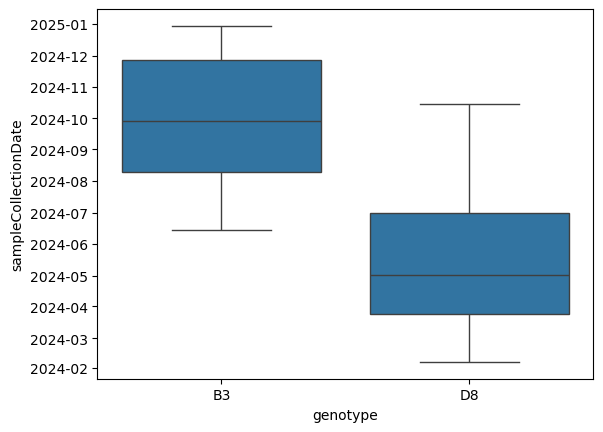

In [6]:
import seaborn as sns

sns.boxplot(
    data=metadata,
    x="genotype",
    y="sampleCollectionDate"
)

(array([19754., 19783., 19814., 19844., 19875., 19905., 19936., 19967.,
        19997., 20028., 20058., 20089.]),
 [Text(19754.0, 0, '2024-02'),
  Text(19783.0, 0, '2024-03'),
  Text(19814.0, 0, '2024-04'),
  Text(19844.0, 0, '2024-05'),
  Text(19875.0, 0, '2024-06'),
  Text(19905.0, 0, '2024-07'),
  Text(19936.0, 0, '2024-08'),
  Text(19967.0, 0, '2024-09'),
  Text(19997.0, 0, '2024-10'),
  Text(20028.0, 0, '2024-11'),
  Text(20058.0, 0, '2024-12'),
  Text(20089.0, 0, '2025-01')])

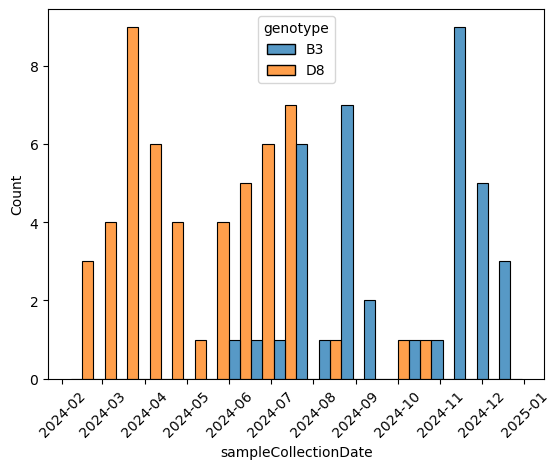

In [9]:
import matplotlib.pyplot as plt

sns.histplot(
    data=metadata,
    x="sampleCollectionDate",
    hue="genotype",
    multiple="dodge",
    bins=20,
)
plt.xticks(rotation=45)

In [10]:
metadata.to_csv("Netherlands_2024_measles_metadata.csv", index=False)
ids = metadata["accessionVersion"].tolist()

d8_metadata = metadata[metadata["genotype"] == "D8"]
d8_metadata.to_csv("Netherlands_2024_measles_D8_metadata.csv", index=False)
d8_ids = d8_metadata["accessionVersion"].tolist()

In [12]:
import requests
from io import StringIO

url = "https://lapis.pathoplexus.org/measles/sample/alignedNucleotideSequences?downloadAsFile=true&downloadFileBasename=measles_aligned-nuc_2026-03-02T1955&dataUseTerms=OPEN&dataFormat=fasta&versionStatus=LATEST_VERSION&isRevocation=false&genotype=D8&genotype=B3&geoLocCountry=Netherlands&lengthFrom=14000&sampleCollectionDateRangeLowerFrom=2024-01-01&sampleCollectionDateRangeUpperTo=2024-12-31"
response = requests.get(url)
response.raise_for_status()  # Ensure the request was successful

fasta_io = StringIO(response.text)

with open("Netherlands_2024_measles_sequences.fasta", "w") as netherlands_fasta:
    with open("Netherlands_2024_measles_D8_sequences.fasta", "w") as d8_fasta:


        for sequence in SeqIO.parse(fasta_io, "fasta"):
            if sequence.id in ids:
                SeqIO.write(sequence, netherlands_fasta, "fasta")
            if sequence.id in d8_ids:
                SeqIO.write(sequence, d8_fasta, "fasta")

netherlands_fasta.close()